In [4]:
from astroquery.gaia import Gaia
import pandas as pd

df = pd.read_csv('gaia_disk_stars.csv')

Gaia.login(user='tchopra', password='Tanma')

query = """
SELECT TOP 50000
    source_id,
    l, b,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    radial_velocity, radial_velocity_error,
    phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE
    b BETWEEN -10 AND 10
    AND parallax > 0
    AND parallax_over_error > 5
    AND phot_g_mean_mag < 14
    AND radial_velocity IS NOT NULL
"""

job = Gaia.launch_job(query)
results = job.get_results()
df = results.to_pandas()

df.to_csv('gaia_disk_stars.csv', index=False)
print(f"Downloaded {len(df)} stars")
print(df.head())

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
Downloaded 50000 stars
            source_id           l         b  parallax  parallax_error  \
0  196704386853131136  166.954802  9.672545  0.419377        0.019598   
1  196809385917525248  166.698562  9.121140  1.545846        0.025364   
2  196819251458196736  166.676893  9.572840  0.801760        0.034615   
3  196838767789939072  166.513541  9.135927  0.388103        0.013058   
4  196848556019275392  166.504230  9.048881  1.075750        0.016816   

       pmra  pmra_error     pmdec  pmdec_error  radial_velocity  \
0  1.199086    0.020156 -2.580777     0.015583       -21.037836   
1 -4.809770    0.025481 -9.206941     0.018036        24.007170   
2  1.064171    0.024948 -4.277223     0.021116       -26.416351   
3 -0.548296    0.015329 -3.419999     0.010925       -10.185758   
4 -4.776368    0.017

In [3]:
import astropy.units as u
import astropy.coordinates as coord
import numpy as np

# Define Galactocentric frame
gc_frame = coord.Galactocentric(
    galcen_distance=8.15 * u.kpc,
    galcen_v_sun=coord.CartesianDifferential(
        [11.1, 236 + 12.24, 7.25] * u.km/u.s
    ),
    z_sun=25 * u.pc
)

# Build SkyCoord object
c = coord.SkyCoord(
    l=df['l'].values * u.deg,
    b=df['b'].values * u.deg,
    distance=(1000/df['parallax'].values) * u.pc,
    pm_l_cosb=df['pmra'].values * u.mas/u.yr,
    pm_b=df['pmdec'].values * u.mas/u.yr,
    radial_velocity=df['radial_velocity'].values * u.km/u.s,
    frame='galactic'
)

# Transform to galactocentric
gc = c.galactocentric

# Galactocentric radius
R = np.sqrt(gc.x.to(u.kpc).value**2 + gc.y.to(u.kpc).value**2)

# Azimuthal velocity (rotation)
phi = np.arctan2(gc.y.value, gc.x.value)
v_phi = np.abs(-gc.v_x.to(u.km/u.s).value * np.sin(phi) +
                gc.v_y.to(u.km/u.s).value * np.cos(phi))

print(f"R range: {R.min():.2f} to {R.max():.2f} kpc")
print(f"v_phi range: {v_phi.min():.1f} to {v_phi.max():.1f} km/s")

R range: 8.13 to 21.29 kpc
v_phi range: 0.6 to 341.4 km/s


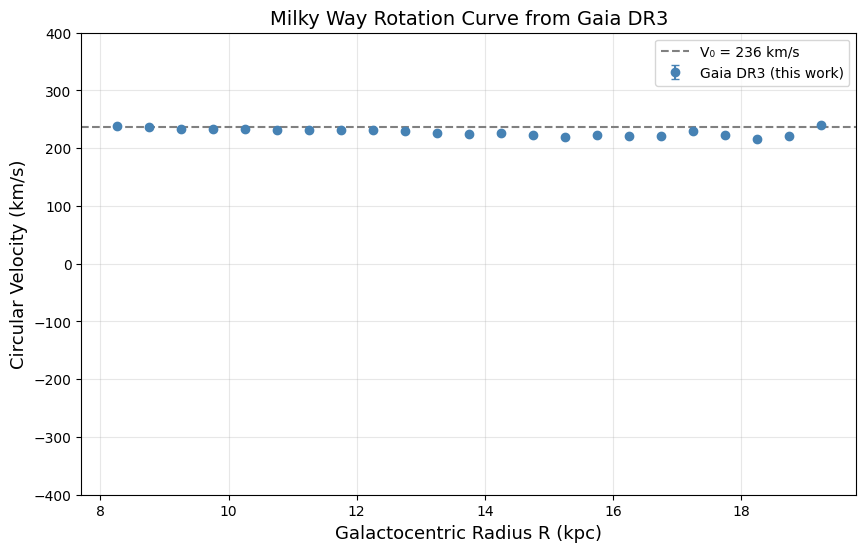

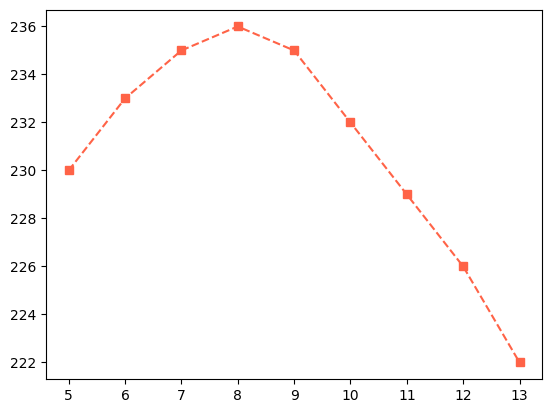

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# Bin by galactocentric radius
R_bins = np.arange(8, 20, 0.5)  # adjusted to your actual R range

v_median, bin_edges, _ = binned_statistic(R, v_phi, statistic='median', bins=R_bins)
v_std, _, _ = binned_statistic(R, v_phi, statistic='std', bins=R_bins)
R_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(10, 6))
plt.errorbar(R_centers, v_median, yerr=v_std/np.sqrt(500),
             fmt='o', color='steelblue', capsize=3, label='Gaia DR3 (this work)')

# Reference line at Sun's circular velocity
plt.axhline(y=236, color='gray', linestyle='--', label='V₀ = 236 km/s')

plt.xlabel('Galactocentric Radius R (kpc)', fontsize=13)
plt.ylabel('Circular Velocity (km/s)', fontsize=13)
plt.title('Milky Way Rotation Curve from Gaia DR3', fontsize=14)
plt.ylim(-400, 400)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('rotation_curve.png', dpi=150)
plt.show()

# Eilers+2019 values (read from their published figure)
eilers_R = [5, 6, 7, 8, 9, 10, 11, 12, 13]
eilers_vc = [230, 233, 235, 236, 235, 232, 229, 226, 222]
plt.plot(eilers_R, eilers_vc, 's--', color='tomato', label='Eilers+2019')